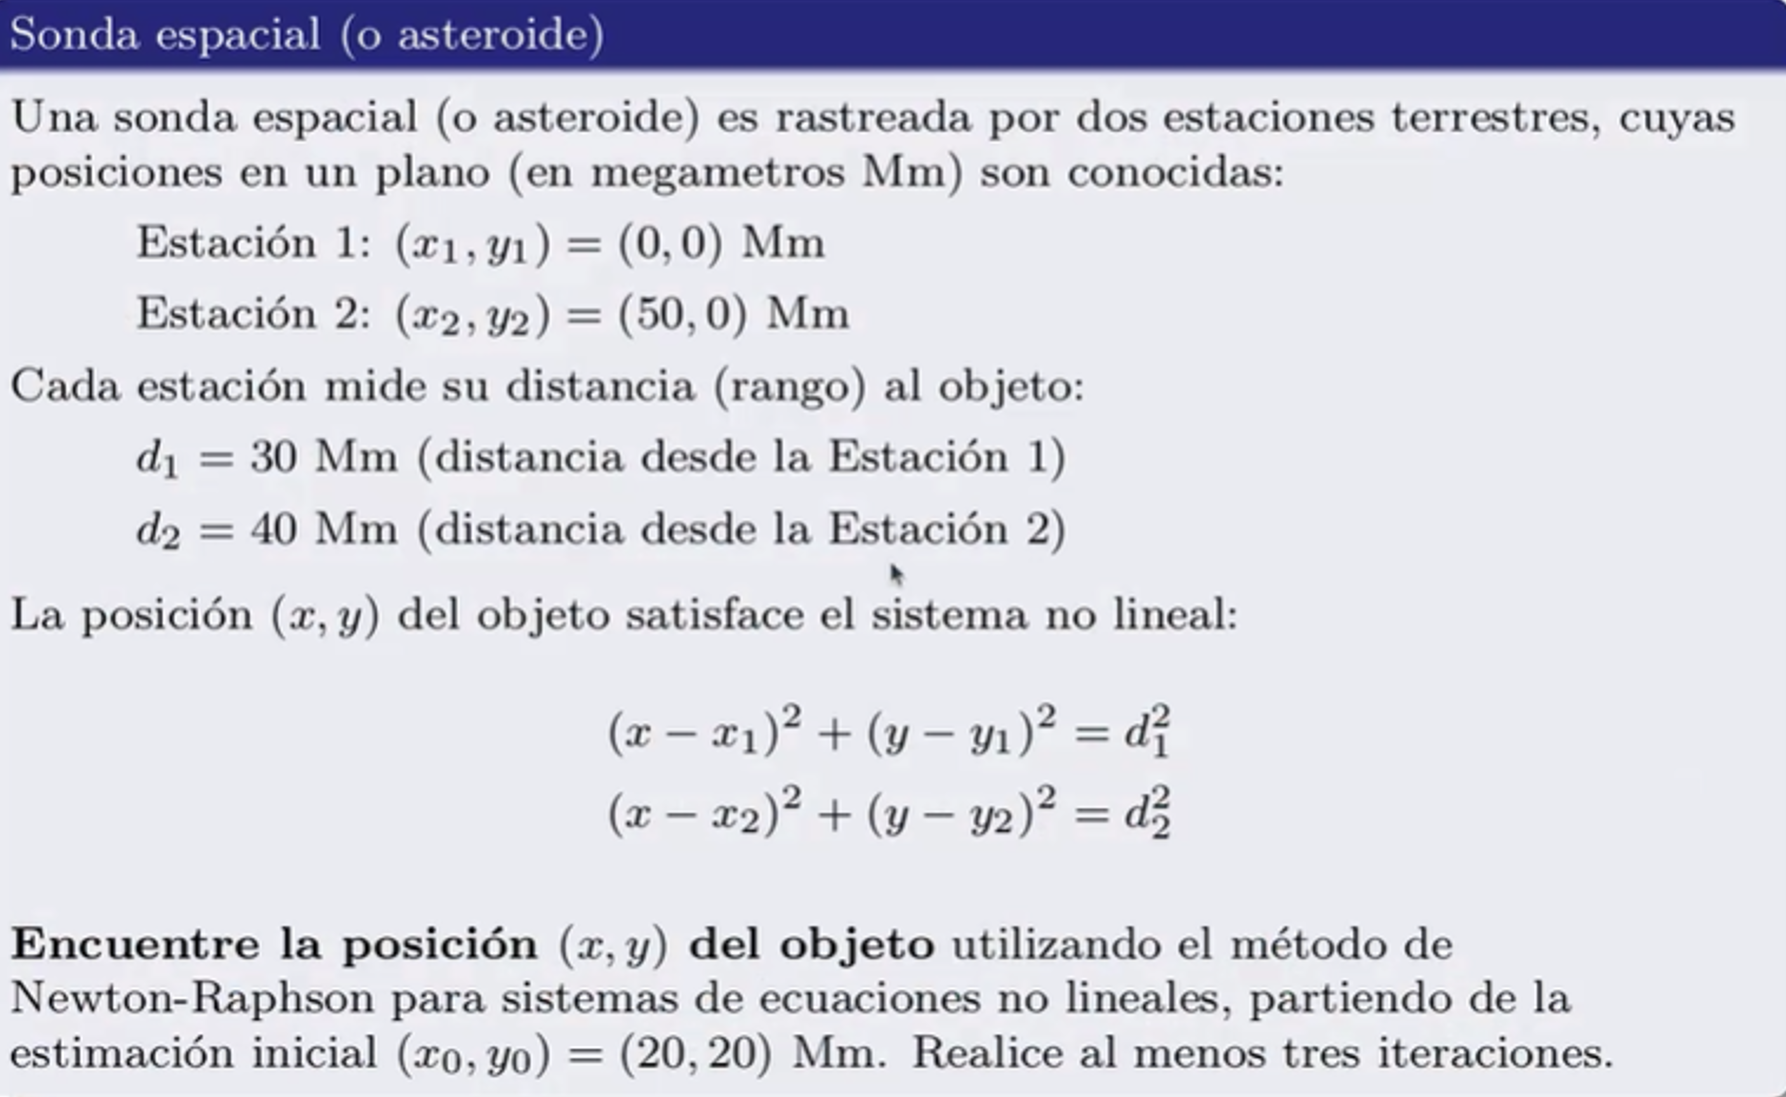

In [4]:
import numpy as np

# Posiciones de las estaciones y distancias medidas (Mm)
x1 = 0
y1 = 0
x2 = 50
y2 = 0

d1 = 30
d2 = 40

# Estimacion inicial (x0, y0)
x = 20
y = 20

# Parametros para el bucle de iteraciones
max_iter = 5
iteracion = 0

while iteracion < max_iter:
    iteracion = iteracion + 1
    
    # Evaluacion de las funciones f1 y f2
    f1 = (x - x1)**2 + (y - y1)**2 - d1**2
    f2 = (x - x2)**2 + (y - y2)**2 - d2**2
    
    # Construccion del vector independiente -F
    b0 = -f1
    b1 = -f2
    
    # Evaluacion de las derivadas parciales 
    j00 = 2.0 * (x - x1)
    j01 = 2.0 * (y - y1)
    j10 = 2.0 * (x - x2)
    j11 = 2.0 * (y - y2)
    
    # Matriz aumentada A = [J | -F]
    A00 = j00
    A01 = j01
    A02 = b0
    A10 = j10
    A11 = j11
    A12 = b1
    
    # Eliminacion Gaussiana con Pivoteo Parcial
    if abs(A10) > abs(A00):
        # Intercambio de fila 0 y fila 1
        A00, A10 = A10, A00
        A01, A11 = A11, A01
        A02, A12 = A12, A02
        
    # Eliminacion hacia adelante
    factor = A10 / A00
    A10 = A10 - factor * A00
    A11 = A11 - factor * A00
    A11 = A11 - factor * (A01 - A00) 
    A11 = j11 - factor * j01
    A12 = b1 - factor * b0
    
    # Sustitucion hacia atras
    dy = A12 / A11
    dx = (A02 - A01 * dy) / A00
    
    # Actualizacion de las variables
    x = x + dx
    y = y + dy
    
    # Error de la iteracion
    norma_error = np.sqrt(dx**2 + dy**2)
    
    # Resultados
    print("Iteracion:", iteracion)
    print("dx =", dx, "Mm, dy =", dy, "Mm")
    print("Posicion actualizada: x =", x, "Mm, y =", y, "Mm")
    print("Norma del incremento (error):", norma_error)

# Resultados finales
print("RESULTADO FINAL DESPUÉS DE", iteracion, "ITERACIONES")
print("Posicion de la sonda (x, y): (", x, ",", y, ") Mm")

Iteracion: 1
dx = -1.3333333333333333 Mm, dy = 5.5 Mm
Posicion actualizada: x = 18.666666666666668 Mm, y = 25.5 Mm
Norma del incremento (error): 5.659308948783215
Iteracion: 2
dx = -0.3971631205673764 Mm, dy = -1.1160130718954264 Mm
Posicion actualizada: x = 18.26950354609929 Mm, y = 24.383986928104573 Mm
Norma del incremento (error): 1.1845774440619248
Iteracion: 3
dx = -0.155172359130928 Mm, dy = -0.23069680394036565 Mm
Posicion actualizada: x = 18.11433118696836 Mm, y = 24.153290124164208 Mm
Norma del incremento (error): 0.2780278338342354
Iteracion: 4
dx = -0.06495184397379385 Mm, dy = -0.08734556298923617 Mm
Posicion actualizada: x = 18.049379342994566 Mm, y = 24.065944561174973 Mm
Norma del incremento (error): 0.10884846994562065
Iteracion: 5
dx = -0.027895123008240257 Mm, dy = -0.03728050174140888 Mm
Posicion actualizada: x = 18.021484219986327 Mm, y = 24.028664059433563 Mm
Norma del incremento (error): 0.046561504461690724
RESULTADO FINAL DESPUÉS DE 5 ITERACIONES
Posicion de la